## Installing and Importing Required Libraries

In [1]:
!pip install -q python-dotenv
!pip install -q anthropic


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import base64
import os
import requests
import json
import re

import anthropic
from dotenv import load_dotenv
load_dotenv()

True

## Importing the Dataset

In [3]:
# The full US Accidents dataset is ~7.7 million rows (about 3 GB), which is far more
# than we need for a tutorial. We stream the CSV in chunks and draw a reproducible
# 100,000-row random sample (random_state=42), keeping only the columns relevant to
# accident hotspots, timing, weather, and severity. If you would rather skip the 3 GB
# download, load the included sample instead: dataset = pd.read_csv("us_accidents_sample.csv")

SRC = "US_Accidents_March23.csv"
TOTAL_ROWS = 7_728_394
SAMPLE_N = 100_000
SEED = 42

USECOLS = ["Severity", "Start_Time", "State", "City", "Temperature(F)", "Humidity(%)",
           "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Weather_Condition",
           "Sunrise_Sunset", "Distance(mi)"]

frac = (SAMPLE_N * 1.15) / TOTAL_ROWS
parts = []
for chunk in pd.read_csv(SRC, usecols=USECOLS, chunksize=500_000):
    parts.append(chunk.sample(frac=frac, random_state=SEED))
dataset = pd.concat(parts, ignore_index=True)

# GridDB does not allow parentheses, %, or spaces in column names, so rename the
# weather/road columns to safe equivalents before we build the container schema.
dataset = dataset.rename(columns={
    "Temperature(F)": "Temperature_F", "Humidity(%)": "Humidity_pct",
    "Visibility(mi)": "Visibility_mi", "Wind_Speed(mph)": "Wind_Speed_mph",
    "Precipitation(in)": "Precipitation_in", "Distance(mi)": "Distance_mi"})

# Keep rows with the essential dimensions, parse the timestamp, and derive time features.
dataset = dataset.dropna(subset=["Start_Time", "State", "Severity"]).copy()
dataset["Start_Time"] = pd.to_datetime(dataset["Start_Time"], errors="coerce")
dataset = dataset.dropna(subset=["Start_Time"]).copy()
# Cast the integer time features to int64 so GridDB maps them to LONG. The pandas
# .dt accessors return int32, which our type map would otherwise store as STRING.
dataset["Year"]    = dataset["Start_Time"].dt.year.astype("int64")
dataset["Month"]   = dataset["Start_Time"].dt.month.astype("int64")
dataset["Weekday"] = dataset["Start_Time"].dt.day_name()
dataset["Hour"]    = dataset["Start_Time"].dt.hour.astype("int64")

dataset = dataset.sample(n=SAMPLE_N, random_state=SEED).sort_values("Start_Time").reset_index(drop=True)
dataset["Start_Time"] = dataset["Start_Time"].dt.strftime("%Y-%m-%d %H:%M:%S")

dataset = dataset[["Severity", "Start_Time", "Year", "Month", "Weekday", "Hour", "State",
                   "City", "Weather_Condition", "Temperature_F", "Humidity_pct",
                   "Visibility_mi", "Wind_Speed_mph", "Precipitation_in",
                   "Sunrise_Sunset", "Distance_mi"]]

print(dataset.shape)
dataset.head()

(100000, 16)


,Severity,Start_Time,Year,Month,Weekday,Hour,State,City,Weather_Condition,Temperature_F,Humidity_pct,Visibility_mi,Wind_Speed_mph,Precipitation_in,Sunrise_Sunset,Distance_mi
0,2,2016-02-08 07:59:35,2016,2,Monday,7,OH,Dayton,Overcast,34.0,100.0,7.0,3.5,NaN,Day,0.00
1,3,2016-02-11 05:30:51,2016,2,Thursday,5,OH,Akron,Light Snow,14.0,74.0,4.0,10.4,0.0,Night,0.01
2,3,2016-02-11 08:29:21,2016,2,Thursday,8,OH,Maple Heights,Overcast,18.0,54.0,10.0,25.3,NaN,Day,0.01
3,2,2016-02-11 08:47:51,2016,2,Thursday,8,WV,Charleston,Scattered Clouds,17.1,56.0,10.0,5.8,NaN,Day,0.00
4,3,2016-02-11 17:10:00,2016,2,Thursday,17,OH,Dayton,Mostly Cloudy,21.0,57.0,10.0,8.1,NaN,Day,0.01


## Inserting Data in GridDB

### Creating a GridDB Connection

In [4]:
username = os.environ.get("username")
password = os.environ.get("password")
base_url = os.environ.get("base_url")


url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Creating a GridDB Container for Traffic Accident Data

In [5]:
dataset.insert(0, "SerialNo", dataset.index + 1)
dataset.columns.name = None

# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":      "LONG",
    "float64":    "DOUBLE",
    "bool":       "BOOL",
    "datetime64": "TIMESTAMP",
    "object":     "STRING",
    "category":   "STRING",
}

# Generate the columns part of the payload dynamically
columns = []
for col, dtype in dataset.dtypes.items():
    griddb_type = type_mapping.get(str(dtype), "STRING")
    columns.append({
        "name": col,
        "type": griddb_type
    })

print(columns)

[{'name': 'SerialNo', 'type': 'LONG'}, {'name': 'Severity', 'type': 'LONG'}, {'name': 'Start_Time', 'type': 'STRING'}, {'name': 'Year', 'type': 'LONG'}, {'name': 'Month', 'type': 'LONG'}, {'name': 'Weekday', 'type': 'STRING'}, {'name': 'Hour', 'type': 'LONG'}, {'name': 'State', 'type': 'STRING'}, {'name': 'City', 'type': 'STRING'}, {'name': 'Weather_Condition', 'type': 'STRING'}, {'name': 'Temperature_F', 'type': 'DOUBLE'}, {'name': 'Humidity_pct', 'type': 'DOUBLE'}, {'name': 'Visibility_mi', 'type': 'DOUBLE'}, {'name': 'Wind_Speed_mph', 'type': 'DOUBLE'}, {'name': 'Precipitation_in', 'type': 'DOUBLE'}, {'name': 'Sunrise_Sunset', 'type': 'STRING'}, {'name': 'Distance_mi', 'type': 'DOUBLE'}]


In [6]:
container_name = "traffic_accidents_db"

url = f"{base_url}/containers"

payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,
    "columns": columns
})

response = requests.post(url, headers=headers, data=payload)

print(f"Status Code: {response.status_code}")

Status Code: 201


### Inserting Traffic Accident Records into the GridDB Container

In [7]:
url = f"{base_url}/containers/{container_name}/rows"

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)
        elif isinstance(item, bool):
            formatted.append(str(item).lower())
        elif isinstance(item, (int, float)):
            formatted.append(item)
        else:
            formatted.append(str(item))
    return formatted

rows = [format_row(row) for row in dataset.values.tolist()]

# With 100,000 rows we insert in batches so each request stays a reasonable size.
BATCH_SIZE = 10000
total_inserted = 0

for i in range(0, len(rows), BATCH_SIZE):
    batch = rows[i:i + BATCH_SIZE]
    response = requests.put(url, headers=headers, data=json.dumps(batch))
    if response.status_code != 200:
        print(f"Batch starting at {i} failed: {response.status_code} - {response.text}")
        break
    total_inserted += response.json().get("count", 0)
    print(f"Inserted {total_inserted} / {len(rows)} rows")

print(f"Done. Total inserted: {total_inserted}")

Inserted 10000 / 100000 rows


Inserted 20000 / 100000 rows


Inserted 30000 / 100000 rows


Inserted 40000 / 100000 rows


Inserted 50000 / 100000 rows


Inserted 60000 / 100000 rows


Inserted 70000 / 100000 rows


Inserted 80000 / 100000 rows


Inserted 90000 / 100000 rows


Inserted 100000 / 100000 rows
Done. Total inserted: 100000


## Using AI to Analyze Traffic Accidents

### Retrieve Data from GridDB

In [8]:
url = f"{base_url}/containers/{container_name}/rows"

# With 100,000 rows we page through the container in batches rather than one request.
BATCH_SIZE = 10000
all_rows = []
offset = 0

while True:
    payload = json.dumps({
        "offset": offset,
        "limit": BATCH_SIZE,
        "condition": "",
        "sort": ""
    })
    response = requests.post(url, headers=headers, data=payload)
    if response.status_code != 200:
        print(f"Error at offset {offset}: {response.status_code} - {response.text}")
        break
    chunk = response.json().get("rows", [])
    if not chunk:
        break
    all_rows.extend(chunk)
    offset += len(chunk)
    if len(chunk) < BATCH_SIZE:
        break

accidents_db = pd.DataFrame(all_rows, columns=[col for col in dataset.columns])
print(f"Retrieved {accidents_db.shape[0]} rows")
accidents_db.head()

Retrieved 100000 rows


,SerialNo,Severity,Start_Time,Year,Month,Weekday,Hour,State,City,Weather_Condition,Temperature_F,Humidity_pct,Visibility_mi,Wind_Speed_mph,Precipitation_in,Sunrise_Sunset,Distance_mi
0,1,2,2016-02-08 07:59:35,2016,2,Monday,7,OH,Dayton,Overcast,34.0,100.0,7.0,3.5,NaN,Day,0.00
1,2,3,2016-02-11 05:30:51,2016,2,Thursday,5,OH,Akron,Light Snow,14.0,74.0,4.0,10.4,0.0,Night,0.01
2,3,3,2016-02-11 08:29:21,2016,2,Thursday,8,OH,Maple Heights,Overcast,18.0,54.0,10.0,25.3,NaN,Day,0.01
3,4,2,2016-02-11 08:47:51,2016,2,Thursday,8,WV,Charleston,Scattered Clouds,17.1,56.0,10.0,5.8,NaN,Day,0.00
4,5,3,2016-02-11 17:10:00,2016,2,Thursday,17,OH,Dayton,Mostly Cloudy,21.0,57.0,10.0,8.1,NaN,Day,0.01


### Build Dataset Summary

In [9]:
NUMERIC_COLS = ['Temperature_F', 'Humidity_pct', 'Visibility_mi',
                'Wind_Speed_mph', 'Precipitation_in', 'Distance_mi']

def build_summary(df):
    parts = []
    total = len(df)
    parts.append(f"Records: {total} accidents")
    parts.append(f"Date range: {df['Year'].min()} to {df['Year'].max()}")
    parts.append(f"States covered: {df['State'].nunique()}  |  Cities covered: {df['City'].nunique()}")

    # Severity distribution (1 = least severe, 4 = most severe)
    sev = df['Severity'].value_counts().sort_index()
    sev_tbl = pd.DataFrame({'accidents': sev, 'pct': (sev / total * 100).round(1)})
    sev_tbl.index = [f'severity {i}' for i in sev_tbl.index]
    parts.append(f"\n--- Severity Distribution (1=least, 4=most severe) ---\n{sev_tbl.to_string()}")

    # Accidents and average severity by year
    yr = df.groupby('Year').agg(accidents=('Severity', 'count'), avg_severity=('Severity', 'mean')).round(2)
    parts.append(f"\n--- Accidents and Average Severity by Year ---\n{yr.to_string()}")

    # Top states (hotspots)
    st = df['State'].value_counts().head(10)
    st_tbl = pd.DataFrame({'accidents': st, 'pct': (st / total * 100).round(1)})
    parts.append(f"\n--- Top 10 States by Accident Count (hotspots) ---\n{st_tbl.to_string()}")

    # Top cities (hotspots)
    ct = df['City'].value_counts().head(10)
    parts.append(f"\n--- Top 10 Cities by Accident Count (hotspots) ---\n{ct.to_string()}")

    # Time of day
    hr = df.groupby('Hour').size()
    parts.append(f"\n--- Accidents by Hour of Day (0-23) ---\n{hr.to_string()}")

    # Day of week
    wd_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    wd = df['Weekday'].value_counts().reindex(wd_order)
    parts.append(f"\n--- Accidents by Day of Week ---\n{wd.to_string()}")

    # Day vs night
    ds = df.groupby('Sunrise_Sunset').agg(accidents=('Severity', 'count'), avg_severity=('Severity', 'mean')).round(2)
    parts.append(f"\n--- Day vs Night (accidents + avg severity) ---\n{ds.to_string()}")

    # Weather impact
    wc = df.groupby('Weather_Condition').agg(accidents=('Severity', 'count'), avg_severity=('Severity', 'mean'))
    wc = wc[wc['accidents'] >= 200].sort_values('accidents', ascending=False).head(12).round(2)
    parts.append(f"\n--- Top Weather Conditions (>=200 accidents): count + avg severity ---\n{wc.to_string()}")

    # Numeric conditions overall
    parts.append(f"\n--- Numeric Stats (overall) ---\n{df[NUMERIC_COLS].describe().round(2).to_string()}")

    # Average conditions by severity
    by_sev = df.groupby('Severity')[NUMERIC_COLS].mean().round(2)
    parts.append(f"\n--- Average Conditions by Severity Level ---\n{by_sev.to_string()}")

    return "\n".join(parts)


data_summary = build_summary(accidents_db)
print(data_summary[:600])

Records: 100000 accidents
Date range: 2016 to 2023
States covered: 49  |  Cities covered: 6428

--- Severity Distribution (1=least, 4=most severe) ---
            accidents   pct
severity 1        947   0.9
severity 2      77823  77.8
severity 3      18547  18.5
severity 4       2683   2.7

--- Accidents and Average Severity by Year ---
      accidents  avg_severity
Year                         
2016       5871          2.39
2017      10276          2.39
2018      12807          2.39
2019      13668          2.31
2020      16590          2.18
2021      20175          2.15
2022      18193      


### Create Chatbot

In [10]:
SYSTEM_PROMPT = f"""You are a traffic-safety data analyst. You have records for {len(accidents_db)} US
traffic accidents sampled from the US Accidents dataset. Each record includes the accident severity
(Severity, an integer from 1 = least severe to 4 = most severe), the timestamp (Start_Time) and its
derived Year, Month, Weekday, and Hour, the location (State, City), the Weather_Condition, numeric
conditions (Temperature_F, Humidity_pct, Visibility_mi, Wind_Speed_mph, Precipitation_in), whether the
accident happened during Day or Night (Sunrise_Sunset), and the length of road affected (Distance_mi).

Always ground your answers in the specific numbers from the summary below. Present findings as
data-backed observations rather than established facts, and remember that these are correlations in a
sample, not proof of causation.

DATA:
{data_summary}
"""


class TrafficAccidentChatbot:
    def __init__(self):
        self.client = anthropic.Anthropic()
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2048,
            system=SYSTEM_PROMPT,
            messages=self.history
        )
        answer = response.content[0].text
        self.history.append({"role": "assistant", "content": answer})
        return answer

    def reset(self):
        self.history = []
        print("History cleared.")


chatbot = TrafficAccidentChatbot()
print("Chatbot ready!")

Chatbot ready!


### Ask Questions

In [11]:
# Q1: Accident hotspots
print(chatbot.ask("Which states and cities are the biggest accident hotspots in this dataset, and how concentrated are accidents geographically? Cite specific numbers."))

## Geographic Accident Hotspots

### State-Level Concentration

California dominates the dataset by a wide margin, accounting for **22,325 accidents — 22.3% of all 100,000 records**. That's more than double the next-highest state, Florida (**10,859 accidents, 10.9%**). Texas ranks third at **7,803 accidents (7.8%)**.

The **top 3 states alone (CA, FL, TX) account for roughly 40,987 accidents — about 41% of the entire dataset**, despite the dataset spanning 49 states. The top 10 states collectively represent:

| State | Accidents | % of Total |
|-------|-----------|------------|
| CA | 22,325 | 22.3% |
| FL | 10,859 | 10.9% |
| TX | 7,803 | 7.8% |
| SC | 4,924 | 4.9% |
| NY | 4,473 | 4.5% |
| NC | 4,406 | 4.4% |
| VA | 3,800 | 3.8% |
| PA | 3,731 | 3.7% |
| MN | 2,524 | 2.5% |
| OR | 2,437 | 2.4% |

That's **~67,282 accidents (67.3%) concentrated in just 10 of 49 states** — a notably skewed distribution.

---

### City-Level Concentration

At the city level, concentration is even more s

In [12]:
# Q2: Time-of-day patterns
print(chatbot.ask("What are the busiest times for accidents? Break the pattern down by hour of day and by day of week, and point out the peak periods. Cite specific numbers."))

## Temporal Patterns in Accident Frequency

### Hour of Day

The hourly data reveals a clear **dual-peak "rush hour" pattern**, with notable overnight troughs:

#### Morning Rush (Peak 1)
Accidents climb sharply starting at **4 AM (2,144)** and **5 AM (3,062)**, then surge to the single highest hours of the day:
- **7 AM: 7,790 accidents**
- **8 AM: 7,863 accidents** ← absolute daily peak

After 8 AM, counts drop considerably to **9 AM (4,759)** and stabilize through midday.

#### Midday Plateau
Hours 9 through 13 form a relatively steady plateau ranging from **4,459 (10 AM) to 5,062 (1 PM)** — elevated but well below rush-hour peaks.

#### Afternoon Rush (Peak 2)
A second surge builds through the afternoon:
- **2 PM: 5,672**
- **3 PM: 6,708**
- **4 PM: 7,595**
- **5 PM: 7,424**

The afternoon peak is slightly **lower and broader** than the morning spike, spreading across roughly four hours (2–5 PM) compared to the sharper morning concentration.

#### Evening Decline and Overnight Trou

In [13]:
# Q3: Follow-up on weather and severity
print(chatbot.ask("Building on those peak times, how do weather conditions and day-versus-night relate to accident severity? Which conditions show the highest average severity, and what does the year-over-year severity trend look like?"))

## Weather, Daylight, and Severity Patterns

### Day vs. Night

Perhaps the most surprising finding in the dataset is how **little daylight conditions appear to matter for average severity**. Both day and night accidents share an identical average severity of **2.23**, despite a substantial difference in volume:
- **Day: 69,388 accidents**
- **Night: 30,358 accidents**

The daytime dominance in raw counts aligns with the rush-hour commuter pattern established earlier — most accidents happen during daylight business hours. However, the equal severity scores suggest that **nighttime driving does not produce measurably worse outcomes in this sample**, at least as captured by this metric. This is counterintuitive relative to common assumptions about night driving risk, and may reflect the lower traffic volumes and speeds during overnight hours partially offsetting reduced visibility.

---

### Weather Condition and Severity

Among weather conditions with at least 200 accidents, average sev

### Execute Code and Generate Charts

In [14]:
client = anthropic.Anthropic()

def generate_and_run_chart(question):
    """
    Ask Claude to generate matplotlib code for a chart, then execute it.
    The chart displays inline in the notebook.
    """
    schema = f"Columns: {list(accidents_db.columns)}\nSample:\n{accidents_db.head(3).to_csv(index=False)}"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2048,
        messages=[{
            "role": "user",
            "content": f"""I have a pandas DataFrame `accidents_db` with this structure:

{schema}

Severity is an integer from 1 (least severe) to 4 (most severe). Hour is 0-23. Weekday is the day
name. Weather_Condition is a string such as 'Fair', 'Cloudy', or 'Light Rain'.

Write Python code using pandas and matplotlib to: {question}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- accidents_db is already loaded, matplotlib.pyplot is imported as plt
- Use plt.figure(figsize=(10, 6)) for good sizing
- Always include plt.tight_layout() and plt.show()
- Add a clear title, axis labels, and a legend where needed"""
        }]
    )

    code = response.content[0].text
    code = re.sub(r'^```python\s*', '', code, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE)
    code = code.strip()

    print("Generated code:")
    print("-" * 40)
    print(code)
    print("-" * 40)
    print("\nExecuting...\n")

    exec(code, globals())

Generated code:
----------------------------------------
state_counts = accidents_db['State'].value_counts().head(10)

fig = plt.figure(figsize=(10, 6))
bars = plt.bar(state_counts.index, state_counts.values, color='steelblue', edgecolor='black', label='Number of Accidents')

for bar, count in zip(bars, state_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(state_counts.values) * 0.01,
             f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Top 10 States by Number of Accidents', fontsize=16, fontweight='bold')
plt.xlabel('State', fontsize=13)
plt.ylabel('Number of Accidents', fontsize=13)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, max(state_counts.values) * 1.12)
plt.tight_layout()
plt.show()
----------------------------------------

Executing...



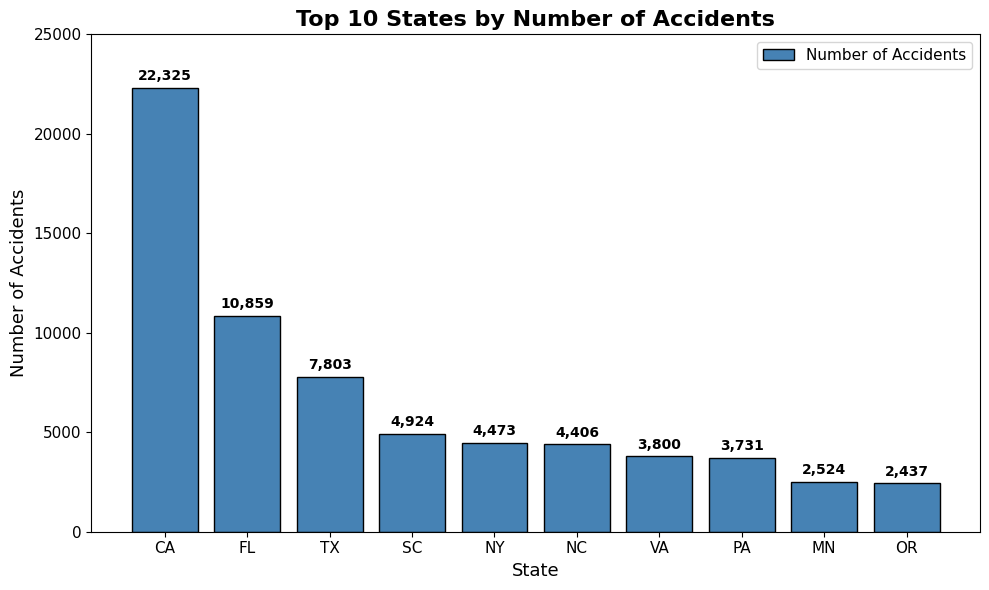

In [15]:
# Chart 1: Accident hotspots by state
generate_and_run_chart("A bar chart of the top 10 states by number of accidents, sorted descending. Put the count on top of each bar.")

Generated code:
----------------------------------------
plt.figure(figsize=(10, 6))

hourly_accidents = accidents_db.groupby('Hour').size()

plt.bar(hourly_accidents.index, hourly_accidents.values, color='steelblue', edgecolor='black', alpha=0.8, label='Number of Accidents')

plt.title('Number of Accidents by Hour of the Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=13)
plt.ylabel('Number of Accidents', fontsize=13)
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11)

rush_hours_morning = [7, 8, 9]
rush_hours_evening = [16, 17, 18]
for hour in rush_hours_morning:
    if hour in hourly_accidents.index:
        plt.bar(hour, hourly_accidents[hour], color='orange', edgecolor='black', alpha=0.9, label='Morning Rush Hour' if hour == rush_hours_morning[0] else '')
for hour in rush_hours_evening:
    if hour in hourly_accidents.index:
        plt.bar(hour, hourly_accidents[hour], color='tomato', edgecolor='black', alpha=

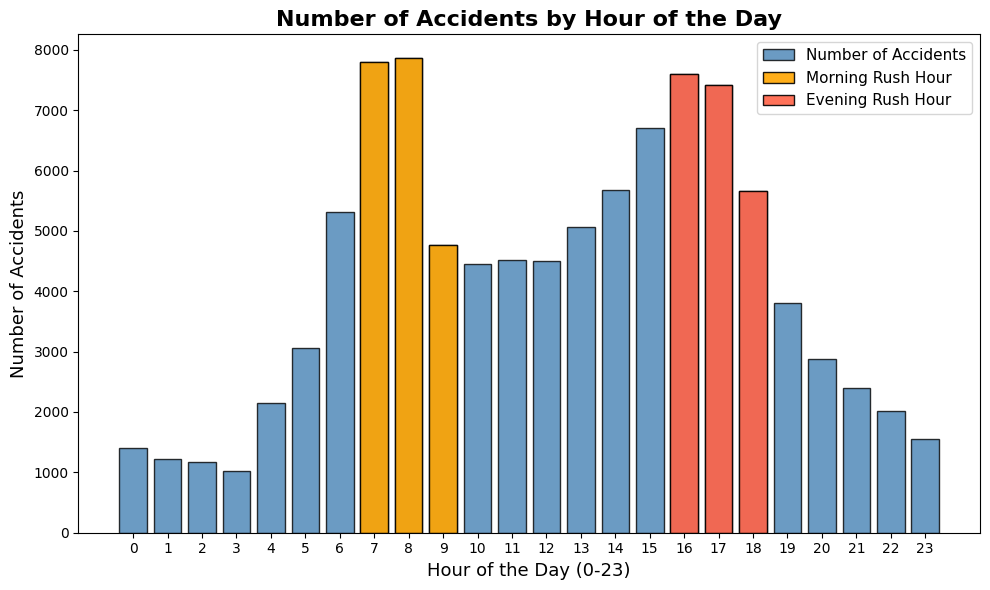

In [16]:
# Chart 2: Accidents by hour of day
generate_and_run_chart("A bar chart showing the number of accidents for each hour of the day from 0 to 23, to reveal the rush-hour peaks.")

Generated code:
----------------------------------------
weather_counts = accidents_db['Weather_Condition'].value_counts()
valid_weather = weather_counts[weather_counts >= 500].index

filtered_db = accidents_db[accidents_db['Weather_Condition'].isin(valid_weather)]

avg_severity = filtered_db.groupby('Weather_Condition')['Severity'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(avg_severity.index, avg_severity.values, color='steelblue', edgecolor='black')

plt.xlabel('Average Severity', fontsize=12)
plt.ylabel('Weather Condition', fontsize=12)
plt.title('Average Accident Severity by Weather Condition\n(Weather conditions with at least 500 accidents)', fontsize=13)

for bar, value in zip(bars, avg_severity.values):
    plt.text(value + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{value:.2f}', va='center', ha='left', fontsize=9)

plt.xlim(0, avg_severity.values.max() + 0.15)
plt.tight_layout()
plt.show()
------------------------------------

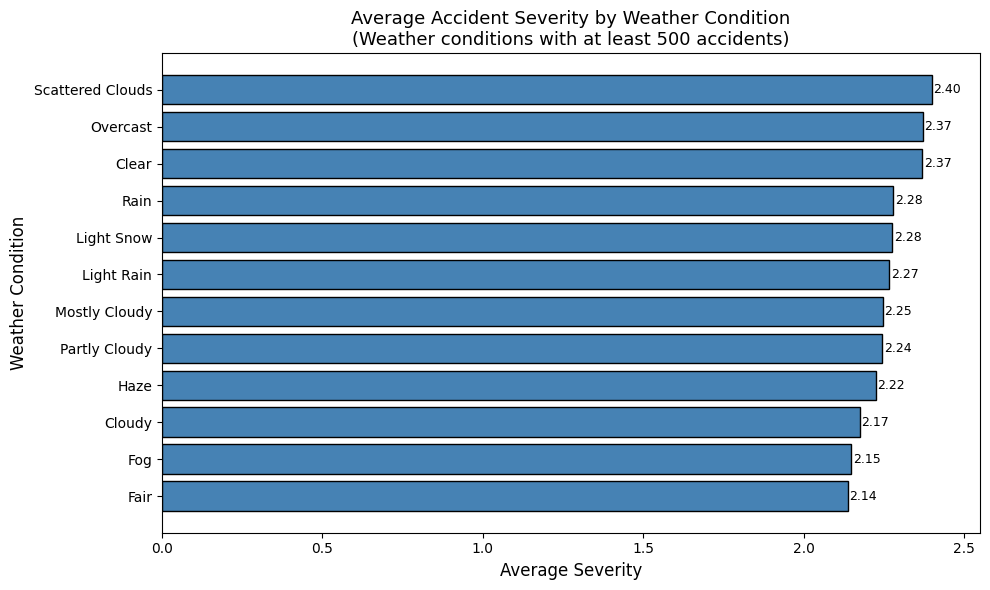

In [17]:
# Chart 3: Weather impact on severity
generate_and_run_chart("A horizontal bar chart of the average accident severity for the weather conditions that have at least 500 accidents, sorted so the highest average severity is at the top.")